# Redes Neuronales II — Parte 3
### La misma red, ahora en PyTorch: reconocer dígitos escritos a mano (MNIST)

---

**Universidad de Cundinamarca**

**CADI:** Deep Learning — Conceptos

**Estudiante:** Ruby Dayana Cárdenas Gómez

**Docente:** Nidia Stella García Roa

**Repositorio GitHub:** `https://github.com/RubyDayana/redes-neuronales-ii.git`

---

### ¿Qué se hace en este notebook?

En la Parte 2 construí con Keras una red densa que reconoce dígitos. Aquí **replico exactamente la misma red**
(784 → 128 ReLU → 64 ReLU → 10) pero con **PyTorch**, la otra herramienta más usada en Deep Learning. La idea
es ver que el modelo es el mismo y lo que cambia es la forma de escribirlo, y al final comparar los resultados.

### Keras y PyTorch: ¿en qué se diferencian?

Las dos hacen lo mismo por dentro. La diferencia está en cuánto le dejan hacer a uno:

| | Keras (Parte 2) | PyTorch (aquí) |
|---|---|---|
| Estilo | "Dime **qué** quieres y yo lo hago" | "Dime **cómo**, paso a paso" |
| Entrenar | Una línea: `modelo.fit(...)` | Uno escribe el ciclo: adelante, error, atrás, corregir |
| Se parece a... | Usar una lavadora: eliges el programa | La Parte 1 con NumPy, pero sin calcular derivadas a mano |
| Quién lo usa más | Cuando se quiere algo rápido y estándar | Investigación, o cuando se quiere controlar cada detalle |

Lo bonito de PyTorch es que el ciclo de entrenamiento se ve **igual** al que escribí en la Parte 1: hacia
adelante, medir el error, hacia atrás, corregir. Solo que la parte de "hacia atrás" (calcular la culpa de cada
uno de los 109 386 pesos) la hace PyTorch con una sola línea: `error.backward()`.

**No se usan redes convolucionales.**

---
## 1. Los datos

PyTorch trae MNIST en su librería de visión, `torchvision`. Se descarga solo la primera vez.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import datasets

torch.manual_seed(42)     # para que los resultados no cambien cada vez que se ejecuta
np.random.seed(42)

print("PyTorch versión:", torch.__version__)

# Si Colab tiene GPU la usamos; si no, funciona igual con CPU (solo más lento)
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
print("Entrenando en:", dispositivo)

mnist_ent = datasets.MNIST(root="./data", train=True,  download=True)
mnist_pru = datasets.MNIST(root="./data", train=False, download=True)

print()
print("Imágenes de entrenamiento:", tuple(mnist_ent.data.shape))
print("Imágenes de prueba       :", tuple(mnist_pru.data.shape))
print("Primeras 10 etiquetas    :", mnist_ent.targets[:10].tolist())

PyTorch versión: 2.14.0+cu130
Entrenando en: cpu



Imágenes de entrenamiento: (60000, 28, 28)
Imágenes de prueba       : (10000, 28, 28)
Primeras 10 etiquetas    : [5, 0, 4, 1, 9, 2, 1, 3, 1, 4]


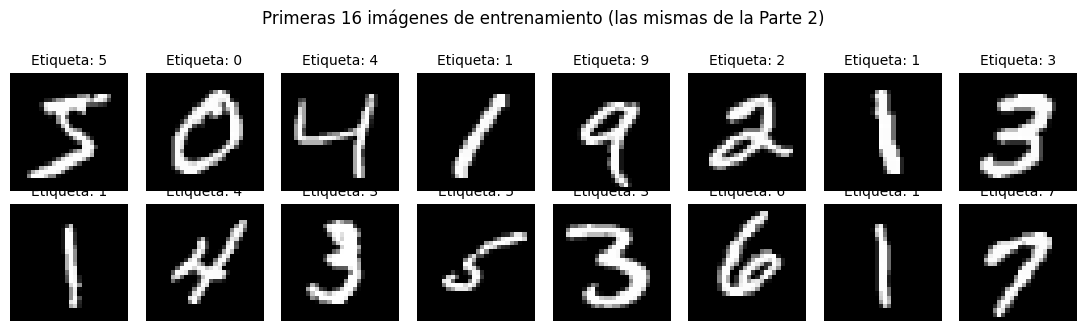

In [2]:
fig, ejes = plt.subplots(2, 8, figsize=(11, 3.2))
for i, eje in enumerate(ejes.ravel()):
    eje.imshow(mnist_ent.data[i], cmap="gray")
    eje.set_title(f"Etiqueta: {mnist_ent.targets[i].item()}", fontsize=10)
    eje.axis("off")
plt.suptitle("Primeras 16 imágenes de entrenamiento (las mismas de la Parte 2)", y=1.02)
plt.tight_layout(); plt.show()

### 1.1. Preparar los datos

Los mismos dos pasos de la Parte 2: **aplanar** cada imagen a 784 números y **escalar** los píxeles a 0–1.
La única diferencia es que en PyTorch los datos se guardan en **tensores**, que son como los arreglos de NumPy
pero pueden vivir en la GPU y recuerdan las operaciones que se les hacen (eso es lo que permite calcular las
derivadas automáticamente).

También aparto el 10 % de las imágenes de entrenamiento para validación, como hizo Keras.

In [3]:
# Aplanar y escalar (float32 es el tipo de número con el que trabajan las redes)
X_ent = mnist_ent.data.reshape(-1, 784).float() / 255.0
Y_ent = mnist_ent.targets
X_pru = mnist_pru.data.reshape(-1, 784).float() / 255.0
Y_pru = mnist_pru.targets

# Separar validación: 54 000 para entrenar, 6 000 para validar
n_val = 6000
X_val, Y_val = X_ent[-n_val:], Y_ent[-n_val:]
X_ent, Y_ent = X_ent[:-n_val], Y_ent[:-n_val]

print("Entrenamiento:", tuple(X_ent.shape), " valores entre", X_ent.min().item(), "y", X_ent.max().item())
print("Validación   :", tuple(X_val.shape))
print("Prueba       :", tuple(X_pru.shape))

Entrenamiento: (54000, 784)  valores entre 0.0 y 1.0
Validación   : (6000, 784)
Prueba       : (10000, 784)


### 1.2. Entregar los datos por grupos

En la Parte 1 escribí una función `lotes()` que revolvía los datos y los entregaba en grupos de 32. PyTorch
tiene lo mismo ya hecho: el `DataLoader`. Le doy los datos, el tamaño del grupo, y le digo que revuelva.

In [4]:
from torch.utils.data import TensorDataset, DataLoader

TAMANO_LOTE = 32

cargador_ent = DataLoader(TensorDataset(X_ent, Y_ent), batch_size=TAMANO_LOTE, shuffle=True)
cargador_val = DataLoader(TensorDataset(X_val, Y_val), batch_size=1000)
cargador_pru = DataLoader(TensorDataset(X_pru, Y_pru), batch_size=1000)

print(f"Grupos por época: {len(cargador_ent)}  (54 000 imágenes / {TAMANO_LOTE} por grupo)")

# Un vistazo a un grupo
X_grupo, Y_grupo = next(iter(cargador_ent))
print("Forma de un grupo de entradas :", tuple(X_grupo.shape))
print("Forma de un grupo de etiquetas:", tuple(Y_grupo.shape), "->", Y_grupo[:10].tolist())

Grupos por época: 1688  (54 000 imágenes / 32 por grupo)
Forma de un grupo de entradas : (32, 784)
Forma de un grupo de etiquetas: (32,) -> [1, 8, 6, 7, 4, 8, 3, 0, 1, 9]


---
## 2. Construir la red

La misma red de la Parte 2, escrita en PyTorch. `nn.Sequential` es el equivalente de `keras.Sequential` y
`nn.Linear` es el equivalente de `Dense`.

```
   784 entradas  ->  128 neuronas [ReLU]  ->  64 neuronas [ReLU]  ->  10 salidas
```

**Un detalle importante:** en PyTorch la última capa **no lleva softmax**. La función de error que voy a usar
(`CrossEntropyLoss`) ya lo aplica por dentro, y hacerlo dos veces daría resultados peores. Es solo una
diferencia de dónde se escribe; la red hace lo mismo.

In [5]:
modelo = nn.Sequential(
    nn.Linear(784, 128),   # capa oculta 1: 784 entradas -> 128 neuronas
    nn.ReLU(),
    nn.Linear(128, 64),    # capa oculta 2: 128 -> 64
    nn.ReLU(),
    nn.Linear(64, 10),     # salida: 64 -> 10 (una por dígito). El softmax lo aplica la función de error.
).to(dispositivo)

print(modelo)

# Contar los parámetros (pesos + sesgos) para comprobar que es la misma red de Keras
n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"\nParámetros por capa:")
for nombre, p in modelo.named_parameters():
    print(f"  {nombre:10s} {str(tuple(p.shape)):12s} -> {p.numel():7d}")
print(f"\nTotal: {n_parametros:,} parámetros  (en Keras también dio 109 386)")

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)

Parámetros por capa:
  0.weight   (128, 784)   ->  100352
  0.bias     (128,)       ->     128
  2.weight   (64, 128)    ->    8192
  2.bias     (64,)        ->      64
  4.weight   (10, 64)     ->     640
  4.bias     (10,)        ->      10

Total: 109,386 parámetros  (en Keras también dio 109 386)


---
## 3. Entrenar: el ciclo escrito a mano

Aquí está la diferencia real con Keras. Lo que allá hizo `fit` en una línea, aquí se escribe. Pero fíjate en
que son exactamente los pasos de la Parte 1:

| Parte 1 (NumPy) | Aquí (PyTorch) | Qué hace |
|---|---|---|
| `adelante(red, X)` | `modelo(X)` | Hacia adelante: la red responde |
| `entropia_cruzada(A, Y)` | `funcion_error(salida, Y)` | Medir cuánto se equivocó |
| calcular `deltas` capa por capa | `error.backward()` | **Hacia atrás: la retropropagación**, en una línea |
| `capa.W -= lr * gradiente` | `optimizador.step()` | Corregir los pesos |
| — | `optimizador.zero_grad()` | Borrar las culpas del grupo anterior antes de calcular las nuevas |

Uso el mismo optimizador (Adam), el mismo tamaño de grupo (32) y las mismas épocas (10) que en Keras, para que
la comparación sea justa.

In [6]:
funcion_error = nn.CrossEntropyLoss()                                # entropía cruzada (incluye el softmax)
optimizador   = torch.optim.Adam(modelo.parameters(), lr=0.001)      # el mismo Adam de Keras


def evaluar(modelo, cargador):
    """Pasa todos los datos del cargador por la red y devuelve (error promedio, exactitud en %)."""
    modelo.eval()                        # modo evaluación: la red solo responde, no aprende
    error_total, aciertos, total = 0.0, 0, 0
    with torch.no_grad():                # aquí no hace falta recordar operaciones: no se va a retropropagar
        for X, Y in cargador:
            X, Y = X.to(dispositivo), Y.to(dispositivo)
            salida = modelo(X)
            error_total += funcion_error(salida, Y).item() * len(Y)
            aciertos += (salida.argmax(dim=1) == Y).sum().item()
            total += len(Y)
    return error_total / total, aciertos / total * 100


historia = {"error": [], "exactitud": [], "val_error": [], "val_exactitud": []}
EPOCAS = 10

for epoca in range(1, EPOCAS + 1):
    modelo.train()                       # modo entrenamiento: la red aprende
    error_acum, aciertos, total = 0.0, 0, 0

    for X, Y in cargador_ent:            # un grupo de 32 imágenes a la vez
        X, Y = X.to(dispositivo), Y.to(dispositivo)

        optimizador.zero_grad()          # 0) borrar las culpas del grupo anterior
        salida = modelo(X)               # 1) HACIA ADELANTE
        error  = funcion_error(salida, Y)#    medir el error
        error.backward()                 # 2) HACIA ATRÁS: retropropagación automática
        optimizador.step()               # 3) CORREGIR los pesos

        error_acum += error.item() * len(Y)
        aciertos += (salida.argmax(dim=1) == Y).sum().item()
        total += len(Y)

    val_error, val_exactitud = evaluar(modelo, cargador_val)
    historia["error"].append(error_acum / total)
    historia["exactitud"].append(aciertos / total * 100)
    historia["val_error"].append(val_error)
    historia["val_exactitud"].append(val_exactitud)

    print(f"Época {epoca:2d}/{EPOCAS} - error: {error_acum/total:.4f} - exactitud: {aciertos/total*100:.2f} % "
          f"- val_error: {val_error:.4f} - val_exactitud: {val_exactitud:.2f} %")

Época  1/10 - error: 0.2961 - exactitud: 91.46 % - val_error: 0.1257 - val_exactitud: 96.48 %


Época  2/10 - error: 0.1216 - exactitud: 96.34 % - val_error: 0.0972 - val_exactitud: 97.22 %


Época  3/10 - error: 0.0826 - exactitud: 97.40 % - val_error: 0.0849 - val_exactitud: 97.37 %


Época  4/10 - error: 0.0628 - exactitud: 97.99 % - val_error: 0.0736 - val_exactitud: 97.85 %


Época  5/10 - error: 0.0498 - exactitud: 98.36 % - val_error: 0.0798 - val_exactitud: 97.60 %


Época  6/10 - error: 0.0408 - exactitud: 98.72 % - val_error: 0.0796 - val_exactitud: 97.82 %


Época  7/10 - error: 0.0317 - exactitud: 98.95 % - val_error: 0.0892 - val_exactitud: 97.75 %


Época  8/10 - error: 0.0281 - exactitud: 99.08 % - val_error: 0.0956 - val_exactitud: 97.70 %


Época  9/10 - error: 0.0215 - exactitud: 99.29 % - val_error: 0.0887 - val_exactitud: 97.78 %


Época 10/10 - error: 0.0197 - exactitud: 99.34 % - val_error: 0.0981 - val_exactitud: 97.38 %


### 3.1. Cómo fue aprendiendo

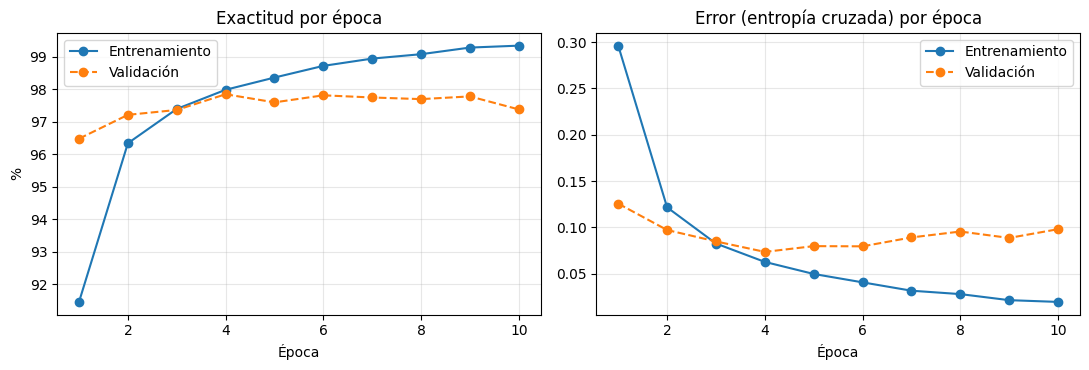

Exactitud final en entrenamiento: 99.34 %
Exactitud final en validación   : 97.38 %


In [7]:
epocas = range(1, EPOCAS + 1)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))

ejes[0].plot(epocas, historia["exactitud"], marker="o", label="Entrenamiento")
ejes[0].plot(epocas, historia["val_exactitud"], marker="o", linestyle="--", label="Validación")
ejes[0].set_title("Exactitud por época"); ejes[0].set_xlabel("Época"); ejes[0].set_ylabel("%")
ejes[0].legend(); ejes[0].grid(alpha=.3)

ejes[1].plot(epocas, historia["error"], marker="o", label="Entrenamiento")
ejes[1].plot(epocas, historia["val_error"], marker="o", linestyle="--", label="Validación")
ejes[1].set_title("Error (entropía cruzada) por época"); ejes[1].set_xlabel("Época")
ejes[1].legend(); ejes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

print(f"Exactitud final en entrenamiento: {historia['exactitud'][-1]:.2f} %")
print(f"Exactitud final en validación   : {historia['val_exactitud'][-1]:.2f} %")

Las curvas tienen la misma forma que en Keras: la red aprende casi todo en las primeras épocas, y el error de
validación deja de bajar mientras el de entrenamiento sigue bajando (el mismo sobreajuste leve de la Parte 2).
Tiene sentido: es la misma red, los mismos datos y el mismo optimizador.

---
## 4. Evaluar con las 10 000 imágenes de prueba

In [8]:
error_prueba, exactitud_prueba = evaluar(modelo, cargador_pru)

print(f"Exactitud en PRUEBA: {exactitud_prueba:.2f} %")
print(f"Error en PRUEBA    : {error_prueba:.4f}")
print()
aciertos = int(round(exactitud_prueba / 100 * len(Y_pru)))
print(f"De 10 000 imágenes, la red acertó {aciertos} y se equivocó en {10000 - aciertos}.")

Exactitud en PRUEBA: 97.46 %
Error en PRUEBA    : 0.1087

De 10 000 imágenes, la red acertó 9746 y se equivocó en 254.


### 4.1. Matriz de confusión

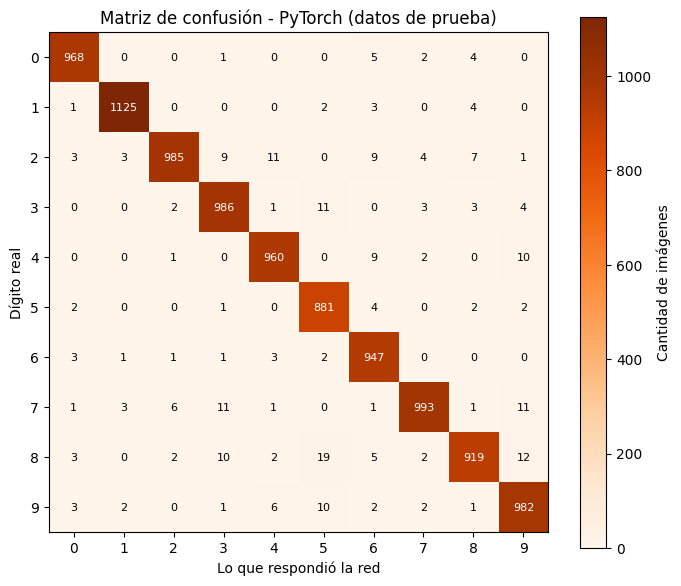

Las 5 confusiones más frecuentes:
  El 8 lo confundió con el 5: 19 veces
  El 8 lo confundió con el 9: 12 veces
  El 7 lo confundió con el 9: 11 veces
  El 7 lo confundió con el 3: 11 veces
  El 3 lo confundió con el 5: 11 veces

Exactitud por dígito:
  Dígito 0: 98.8 %
  Dígito 1: 99.1 %
  Dígito 2: 95.4 %
  Dígito 3: 97.6 %
  Dígito 4: 97.8 %
  Dígito 5: 98.8 %
  Dígito 6: 98.9 %
  Dígito 7: 96.6 %
  Dígito 8: 94.4 %
  Dígito 9: 97.3 %


In [9]:
# Predicciones de todas las imágenes de prueba
modelo.eval()
with torch.no_grad():
    salidas = modelo(X_pru.to(dispositivo))
    probabilidades = torch.softmax(salidas, dim=1).cpu().numpy()   # aquí sí aplico softmax, para leer porcentajes
predicciones = probabilidades.argmax(axis=1)
Y_pru_np = Y_pru.numpy()

matriz = np.zeros((10, 10), dtype=int)
for real, pred in zip(Y_pru_np, predicciones):
    matriz[real, pred] += 1

plt.figure(figsize=(7, 6))
plt.imshow(matriz, cmap="Oranges")
plt.colorbar(label="Cantidad de imágenes")
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Lo que respondió la red"); plt.ylabel("Dígito real")
plt.title("Matriz de confusión - PyTorch (datos de prueba)")
for i in range(10):
    for j in range(10):
        plt.text(j, i, matriz[i, j], ha="center", va="center", fontsize=8,
                 color="white" if matriz[i, j] > matriz.max() / 2 else "black")
plt.tight_layout(); plt.show()

confusiones = [(matriz[i, j], i, j) for i in range(10) for j in range(10) if i != j]
confusiones.sort(reverse=True)
print("Las 5 confusiones más frecuentes:")
for cantidad, real, pred in confusiones[:5]:
    print(f"  El {real} lo confundió con el {pred}: {cantidad} veces")

print()
print("Exactitud por dígito:")
for d in range(10):
    print(f"  Dígito {d}: {matriz[d, d] / matriz[d].sum() * 100:.1f} %")

### 4.2. Viendo las predicciones

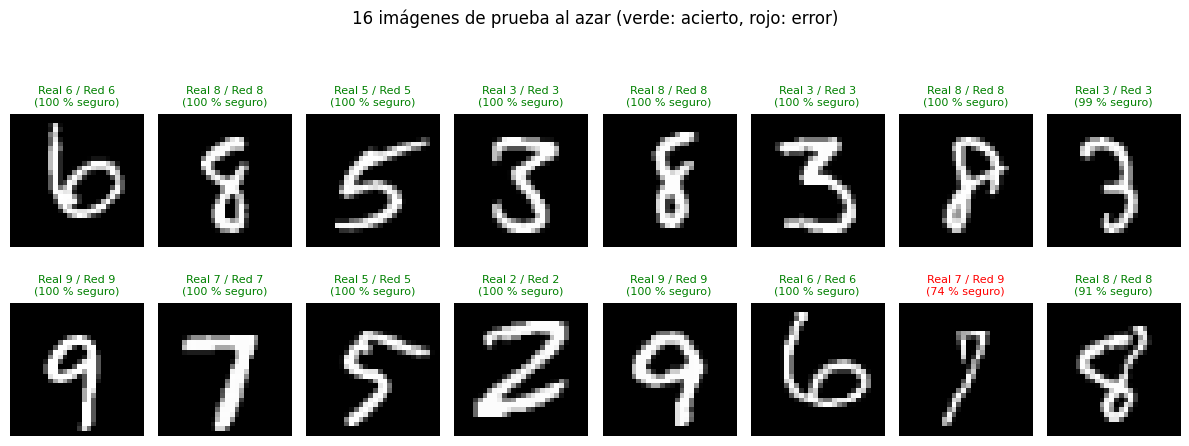

La red se equivocó en 254 de 10000 imágenes. Estas son las primeras 16:


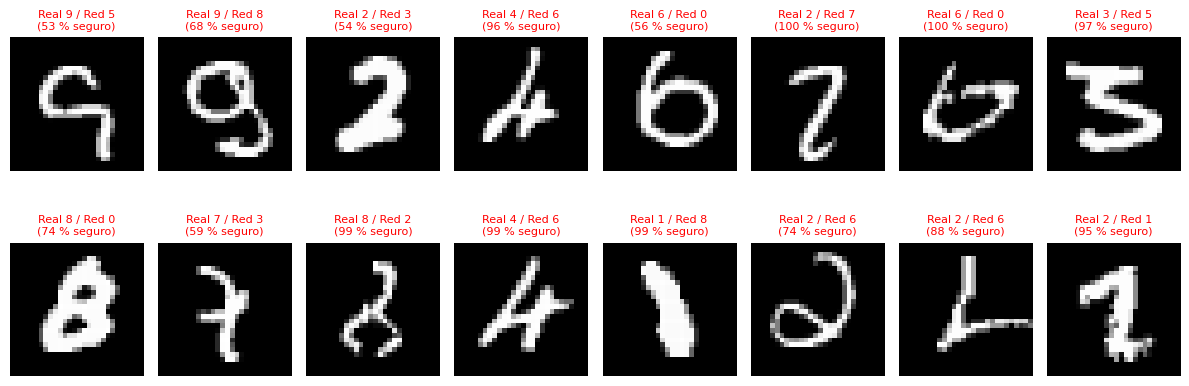

In [10]:
np.random.seed(7)
indices = np.random.choice(len(X_pru), 16, replace=False)

fig, ejes = plt.subplots(2, 8, figsize=(12, 4.6))
for idx, eje in zip(indices, ejes.ravel()):
    real, pred = Y_pru_np[idx], predicciones[idx]
    seguridad = probabilidades[idx][pred] * 100
    color = "green" if real == pred else "red"
    eje.imshow(mnist_pru.data[idx], cmap="gray")
    eje.set_title(f"Real {real} / Red {pred}\n({seguridad:.0f} % seguro)", fontsize=8, color=color)
    eje.axis("off")
plt.suptitle("16 imágenes de prueba al azar (verde: acierto, rojo: error)", y=1.04)
plt.tight_layout(); plt.show()

errores = np.where(predicciones != Y_pru_np)[0]
print(f"La red se equivocó en {len(errores)} de {len(Y_pru_np)} imágenes. Estas son las primeras 16:")

fig, ejes = plt.subplots(2, 8, figsize=(12, 4.6))
for idx, eje in zip(errores[:16], ejes.ravel()):
    real, pred = Y_pru_np[idx], predicciones[idx]
    seguridad = probabilidades[idx][pred] * 100
    eje.imshow(mnist_pru.data[idx], cmap="gray")
    eje.set_title(f"Real {real} / Red {pred}\n({seguridad:.0f} % seguro)", fontsize=8, color="red")
    eje.axis("off")
plt.tight_layout(); plt.show()

---
## 5. Keras vs. PyTorch: comparación final

Misma red, mismos datos, mismo optimizador, mismas épocas. Escribe en la primera línea el valor que te dio el
Notebook 2 para poner los dos resultados lado a lado.

                                  Keras    PyTorch
--------------------------------------------------
Arquitectura                 784-128-64-10 784-128-64-10
Parámetros                      109 386    109 386
Optimizador                        Adam       Adam
Épocas / tamaño de grupo        10 / 32    10 / 32
Exactitud en prueba              97.24 %     97.46 %
Diferencia                                   0.22 puntos


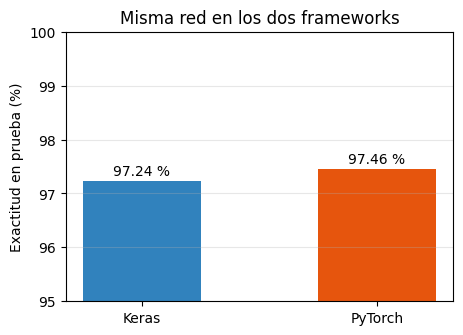

In [11]:
exactitud_keras = 97.24    # <- escribe aquí la exactitud en prueba que salió en el Notebook 2

print(f"{'':28s} {'Keras':>10s} {'PyTorch':>10s}")
print("-" * 50)
print(f"{'Arquitectura':28s} {'784-128-64-10':>10s} {'784-128-64-10':>10s}")
print(f"{'Parámetros':28s} {'109 386':>10s} {f'{n_parametros:,}'.replace(',', ' '):>10s}")
print(f"{'Optimizador':28s} {'Adam':>10s} {'Adam':>10s}")
print(f"{'Épocas / tamaño de grupo':28s} {'10 / 32':>10s} {'10 / 32':>10s}")
print(f"{'Exactitud en prueba':28s} {exactitud_keras:9.2f} % {exactitud_prueba:9.2f} %")
print(f"{'Diferencia':28s} {'':>10s} {abs(exactitud_keras - exactitud_prueba):9.2f} puntos")

plt.figure(figsize=(5, 3.5))
barras = plt.bar(["Keras", "PyTorch"], [exactitud_keras, exactitud_prueba], color=["#3182bd", "#e6550d"], width=0.5)
plt.ylim(95, 100); plt.ylabel("Exactitud en prueba (%)")
plt.title("Misma red en los dos frameworks")
for b_, v in zip(barras, [exactitud_keras, exactitud_prueba]):
    plt.text(b_.get_x() + b_.get_width()/2, v + 0.1, f"{v:.2f} %", ha="center")
plt.grid(axis="y", alpha=.3); plt.show()

---
## 6. Conclusiones

1. **La red es la misma; solo cambia cómo se escribe.** Las dos tienen 109 386 parámetros, las mismas capas y
   las mismas activaciones. Los resultados quedan a unas décimas de distancia, y esa pequeña diferencia viene
   solo del azar (los pesos iniciales y el orden en que se revuelven las imágenes).

2. **PyTorch muestra lo que Keras esconde.** El ciclo de entrenamiento (adelante, error, atrás, corregir) se
   escribe a mano, y se ve que es exactamente el mismo de la Parte 1 con NumPy. La única línea "mágica" es
   `error.backward()`, que calcula la culpa de todos los pesos, lo que en la Parte 1 hice repartiendo los
   `deltas` capa por capa.

3. **Cada herramienta tiene su momento.** Keras es más corto y cómodo para un modelo estándar; PyTorch da
   control sobre cada paso. Haber entendido primero la versión en NumPy es lo que hace que ninguna de las dos
   parezca una caja negra.

4. **Los errores son del mismo tipo.** Los pares exactos cambian un poco de una red a otra, pero siempre son
   dígitos que se parecen al escribirlos (8 y 5, 7 y 9, 3 y 5, 4 y 9). Eso confirma que el límite no está en el framework sino en el tipo de red: una
   red densa mira los píxeles uno por uno y no "ve" formas. Para eso existen las redes convolucionales, que
   quedan fuera de esta actividad.